# Lab 2 Solution: Linear Regression

This solution follows the current worksheet, task by task, including written answers. Run Core tasks from top to bottom; then choose an Advanced investigation. The data URL is the same as in the worksheet and works in a blank Colab notebook. Try the worksheet before opening these answers.

## 0.1 Load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

DATA_URL = "https://raw.githubusercontent.com/wayXing/mps311-439-course-materials/main/lecture-slids/lessons/lesson2/lab/auto_mpg.csv"
cars = pd.read_csv(DATA_URL)

print("Rows and columns:", cars.shape)
cars.head()


Rows and columns: (392, 7)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


## 0.2 Find the car from the lecture

In [2]:
cars[(cars["horsepower"] == 198) & (cars["weight"] == 4341)]


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
5,15.0,8,429.0,198.0,4341,10.0,70


## 0.3 Plot the problem

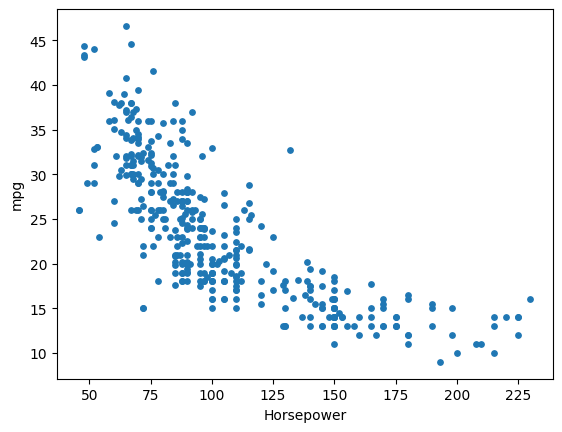

In [3]:
plt.scatter(cars["horsepower"], cars["mpg"], s=15)
plt.xlabel("Horsepower")
plt.ylabel("mpg")
plt.show()


Higher horsepower goes with lower mpg, but the points are widely scattered around the trend. The plot shows an association in these historical cars. It does not show that horsepower causes the lower mpg.

## 1.1 Split before fitting

In [4]:
X = cars.drop(columns="mpg")
y = cars["mpg"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(len(X_train), len(X_test))


313 79


If the line were chosen using the same cars it is judged on, a good score could just mean it fits those cars. Only cars that took no part in fitting can show whether it works on new cars.

## 1.2 Fit a line on horsepower

In [5]:
model = LinearRegression()
model.fit(X_train[["horsepower"]], y_train)

print("Intercept b:", model.intercept_)
print("Slope w:", model.coef_[0])


Intercept b: 40.606097600118346
Slope w: -0.16259724322918448


Each extra horsepower lowers the predicted mpg by about 0.163. A car with zero horsepower does not exist in the data, so the intercept is only the line's starting value.

## 1.3 Predict for a new car

In [6]:
new_car = pd.DataFrame({"horsepower": [100]})
print(model.predict(new_car))


[24.34637328]


## 1.4 Plot the fitted line

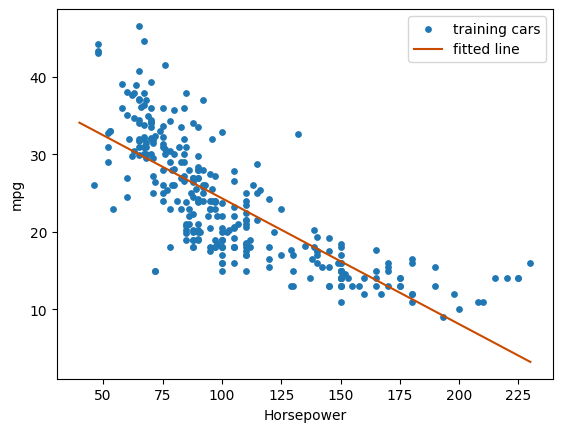

In [7]:
grid = pd.DataFrame({"horsepower": np.linspace(40, 230, 100)})

plt.scatter(X_train["horsepower"], y_train, s=15, label="training cars")
plt.plot(grid["horsepower"], model.predict(grid), color="#C84B00", label="fitted line")
plt.xlabel("Horsepower")
plt.ylabel("mpg")
plt.legend()
plt.show()


The line tends to sit too low for light, low-horsepower cars and for the most powerful cars, and too high in the middle. Keep this in mind for Part 4.

## 2.1 Score two lines by hand

In [8]:
x3 = np.array([130, 165, 150])
y3 = np.array([18, 15, 18])

pred_A = 40 + (-0.15) * x3
pred_B = 40 + (-0.16) * x3
mse_A = np.mean((y3 - pred_A) ** 2)
mse_B = np.mean((y3 - pred_B) ** 2)

print("MSE of line A:", mse_A)
print("MSE of line B:", mse_B)


MSE of line A: 2.1875
MSE of line B: 2.466666666666668


Line A is better on these three cars. The score applies only to the cars it was computed on.

## 2.2 The baseline

In [9]:
baseline = y_train.mean()
baseline_pred = np.full(len(y_test), baseline)
baseline_mse = mean_squared_error(y_test, baseline_pred)

print("Baseline guess:", baseline)
print("Baseline test RMSE:", baseline_mse ** 0.5)


Baseline guess: 23.599361022364217
Baseline test RMSE: 7.184726327203216


The test cars must not influence anything we use to judge the model, and that includes the baseline.

## 2.3 Score the line on the test cars

In [10]:
y_pred = model.predict(X_test[["horsepower"]])

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = 1 - mse / baseline_mse

print("Test RMSE:", rmse)
print("R2:", r2)


Test RMSE: 4.706722545876633
R2: 0.570842471143505


The line (4.71) is better than the baseline (7.18). R² says the line removes about 57% of the baseline's squared error. A lower RMSE describes the typical error. Individual predictions can still be far off.

## 3.1 Add weight

In [11]:
features = ["horsepower", "weight"]

model2 = LinearRegression().fit(X_train[features], y_train)

print("Intercept:", model2.intercept_)
print("Coefficients (horsepower, weight):", model2.coef_)


Intercept: 46.58674143899789
Coefficients (horsepower, weight): [-0.05214672 -0.00587153]


## 3.2 Training error and test error

In [12]:
def rmse(model, columns, X, y):
    return mean_squared_error(y, model.predict(X[columns])) ** 0.5

print("Model 1 (hp):         train", rmse(model, ["horsepower"], X_train, y_train),
      "test", rmse(model, ["horsepower"], X_test, y_test))
print("Model 2 (hp, weight): train", rmse(model2, features, X_train, y_train),
      "test", rmse(model2, features, X_test, y_test))


Model 1 (hp):         train 4.947238449244534 test 4.706722545876633
Model 2 (hp, weight): train 4.240819490930014 test 4.218029885247156


There is no contradiction. With 313 training cars the line is not tailored to a few points, and the two errors are close. A small gap in either direction is ordinary variation between two sets of cars. In the lecture, the large gap came from a line fitted to only three cars.

## 3.3 Why did the horsepower coefficient change?

In [13]:
print(X_train[features].corr())


            horsepower    weight
horsepower    1.000000  0.856179
weight        0.856179  1.000000


Heavy cars also tend to have high horsepower (correlation 0.86). In Model 1, horsepower carries the effect of weight as well. In Model 2, the two features share the credit, so the horsepower coefficient shrinks.

## 3.4 Back to the car

In [14]:
car = cars.loc[[5], features]

print("Predicted mpg:", model2.predict(car))
print("Measured mpg:", cars.loc[5, "mpg"])


Predicted mpg: [10.77335976]
Measured mpg: 15.0


No. An error of 4.2 mpg is about the typical size of Model 2's error on cars it has never seen.

## 4.1 Use all six features

In [15]:
all_features = list(X_train.columns)

model6 = LinearRegression().fit(X_train[all_features], y_train)

print("hp coefficient:", model6.coef_[all_features.index("horsepower")])
print("Test RMSE:", rmse(model6, all_features, X_test, y_test))


hp coefficient: -0.0022763435515019376
Test RMSE: 3.2407360783342587


| Model | hp coefficient | Test RMSE (mpg) |
|---|---:|---:|
| Baseline | | 7.18 |
| 1: hp | -0.163 | 4.71 |
| 2: hp, weight | -0.052 | 4.22 |
| 3: all six features | -0.002 | 3.24 |

## 4.2 Look at the residuals

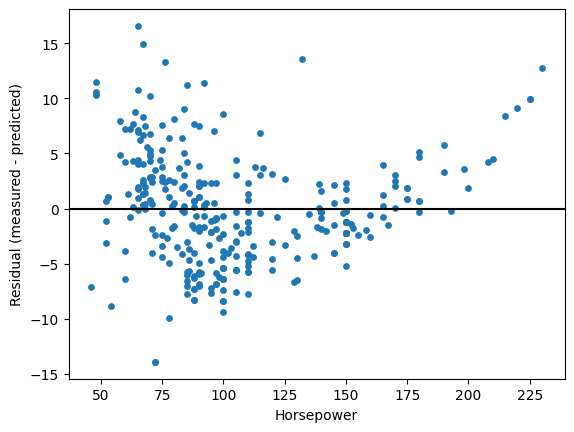

In [16]:
residuals = y_train - model.predict(X_train[["horsepower"]])

plt.scatter(X_train["horsepower"], residuals, s=15)
plt.axhline(0, color="black")
plt.xlabel("Horsepower")
plt.ylabel("Residual (measured - predicted)")
plt.show()


The residuals form a curve: mostly positive at low and at high horsepower, and negative in the middle. This is the same pattern as in 1.4. A straight line misses some of the curvature in these data.

## 4.3 Write your conclusion

For example: On 79 cars the model never saw, the horsepower line has a typical error of 4.71 mpg, against 7.18 for always guessing the mean. The residual plot is curved, so a straight line is not the whole story. Weight, the year and the other features are not in this model, and these data are old cars from one source, so the result does not show a cause or what happens for modern cars.

# Advanced Study

Run the Core tasks first. A, B and C below are worked investigations, including the worksheet self-checks. B can be run without first running A.

## A. Solve the same regression in different ways

In [17]:
# ---- Advanced Study A ----
Xtr2 = X_train[features].to_numpy(); Xte2 = X_test[features].to_numpy()
Xb = np.c_[np.ones(len(Xtr2)), Xtr2]; Xbt = np.c_[np.ones(len(Xte2)), Xte2]
ytr = y_train.to_numpy()
w_solve = np.linalg.solve(Xb.T @ Xb, Xb.T @ ytr)
w_inv = np.linalg.inv(Xb.T @ Xb) @ (Xb.T @ ytr)
w_lstsq = np.linalg.lstsq(Xb, ytr, rcond=None)[0]
print(w_solve, w_inv, w_lstsq)
print("max prediction difference vs sklearn:",
      max(np.abs(Xbt @ w - model2.predict(X_test[features])).max() for w in (w_solve, w_inv, w_lstsq)))
print(np.allclose(w_solve, np.r_[model2.intercept_, model2.coef_]),
      np.allclose(w_inv, w_solve), np.allclose(w_lstsq, w_solve))


[ 4.65867414e+01 -5.21467239e-02 -5.87153429e-03] [ 4.65867414e+01 -5.21467239e-02 -5.87153429e-03] [ 4.65867414e+01 -5.21467239e-02 -5.87153429e-03]
max prediction difference vs sklearn: 1.438849039914203e-13
True True True


In [18]:
X6 = X_train[all_features].to_numpy()
X6b = np.c_[np.ones(len(X6)), X6]
X6s = ((X_train[all_features] - X_train[all_features].mean()) / X_train[all_features].std()).to_numpy()
X6sb = np.c_[np.ones(len(X6s)), X6s]
for name, M in [("raw", X6b), ("standardised", X6sb)]:
    print(name, "cond(X) = %.3g" % np.linalg.cond(M), " cond(X'X) = %.3g" % np.linalg.cond(M.T @ M))


raw cond(X) = 8.78e+04  cond(X'X) = 7.71e+09
standardised cond(X) = 10.8  cond(X'X) = 116


In [19]:
A = np.array([[1.0, 1.0], [1.0, 1.0001]])
print(np.linalg.solve(A, [2.0, 2.0]), np.linalg.solve(A, [2.0, 2.0001]), np.linalg.cond(A))


[2. 0.] [1. 1.] 40002.000074949116


All three solvers reproduce the sklearn fit to numerical precision. Standardising reduces the six-feature condition numbers from about 8.8e4 and 7.7e9 to 11 and 116. The nearly singular 2×2 system changes from (2, 0) to (1, 1) after a 0.0001 change in the second right-hand-side entry. Squaring the condition number in XᵀX makes numerical errors more serious; an explicit inverse is unnecessary.

## B. Gradient descent

In [20]:
# ---- Advanced Study B ----
def gradient_descent(grad, w0, eta, steps):
    w = np.array(w0, dtype=float)
    for _ in range(steps):
        w = w - eta * grad(w)
    return w

for eta in (0.1, 0.5, 1.1):
    print(eta, [float(gradient_descent(lambda w: 2 * (w - 3), 0.0, eta, s)) for s in (1, 2, 5, 20)])
print(gradient_descent(lambda w: 2 * (w - 3), 0.0, 0.5, 1))


0.1 [0.6000000000000001, 1.08, 2.01696, 2.9654123548617948]
0.5 [3.0, 3.0, 3.0, 3.0]
1.1 [6.6000000000000005, -1.3200000000000012, 10.464960000000003, -112.01279977342455]
3.0


In [21]:
ytr = y_train.to_numpy()
Xtr2 = X_train[features].to_numpy()
mu, sd = X_train[features].mean(), X_train[features].std()
Zb = np.c_[np.ones(len(X_train)), ((X_train[features] - mu) / sd).to_numpy()]
Zbt = np.c_[np.ones(len(X_test)), ((X_test[features] - mu) / sd).to_numpy()]
n = len(ytr)
grad = lambda w: 2 / n * Zb.T @ (Zb @ w - ytr)
w_gd = gradient_descent(grad, np.zeros(3), 0.1, 500)
w_ref = np.linalg.lstsq(Zb, ytr, rcond=None)[0]
print("gd:", w_gd, "lstsq:", w_ref)
print("train MSE:", np.mean((Zb @ w_gd - ytr) ** 2))
print("test RMSE gd:", np.mean((Zbt @ w_gd - y_test.to_numpy()) ** 2) ** 0.5, " sklearn model2:", rmse(model2, features, X_test, y_test))


gd: [23.59936102 -1.99636864 -4.93874616] lstsq: [23.59936102 -1.99636793 -4.93874687]
train MSE: 17.98454995465205
test RMSE gd: 4.218029896882835  sklearn model2: 4.218029885247156


In [22]:
with np.errstate(all="ignore"):
    Rb = np.c_[np.ones(n), Xtr2]
    gr = lambda w: 2 / n * Rb.T @ (Rb @ w - ytr)
    print("raw, eta=0.1:", gradient_descent(gr, np.zeros(3), 0.1, 50))
    print("raw, eta=1e-7:", gradient_descent(gr, np.zeros(3), 1e-7, 500))
for eta in (0.01, 0.6):
    with np.errstate(all="ignore"):
        print("standardised, eta =", eta, gradient_descent(grad, np.zeros(3), eta, 500))


raw, eta=0.1: [-inf -inf -inf]
raw, eta=1e-7: [ 0.00034787 -0.00574954  0.00694721]
standardised, eta = 0.01 [23.59839288 -2.34644444 -4.58867031]
standardised, eta = 0.6 [6.35550825e+27 5.92987875e+43 5.92987875e+43]


For the scalar loss, eta=0.5 reaches 3 in one step, eta=0.1 converges gradually, and eta=1.1 oscillates with growing error. On standardised car features, eta=0.1 and 500 steps agree with least squares (training MSE about 17.98; test RMSE about 4.22). Raw features overflow at eta=0.1; a much smaller step avoids overflow but converges slowly. Standardised eta=0.01 is slower and eta=0.6 diverges.

## C. How much can a coefficient move?

hp + weight [-0.08  -0.029]
six features [-0.042  0.029]


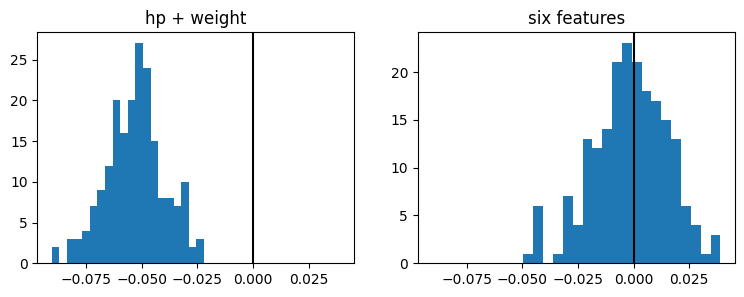

In [23]:
# ---- Advanced Study C ----
rng = np.random.default_rng(0)
def boot_hp(cols, B=200):
    out = []
    for _ in range(B):
        idx = rng.integers(0, len(X_train), len(X_train))
        m = LinearRegression().fit(X_train[cols].iloc[idx], y_train.iloc[idx])
        out.append(m.coef_[cols.index("horsepower")])
    return np.array(out)

b2 = boot_hp(["horsepower", "weight"])
b6 = boot_hp(all_features)
for name, b in [("hp + weight", b2), ("six features", b6)]:
    print(name, np.percentile(b, [2.5, 97.5]).round(3))
fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharex=True)
ax[0].hist(b2, bins=20); ax[0].set_title("hp + weight")
ax[1].hist(b6, bins=20); ax[1].set_title("six features")
for a in ax: a.axvline(0, color="black")
plt.show()


The hp + weight interval remains below zero, whereas the six-feature interval contains zero. The horsepower coefficient is sensitive to the feature set and training sample, especially with strongly correlated predictors; it is not a causal effect. These bootstrap intervals describe resampling variability.

## Advanced Study log

Record your chosen investigation, what you found, how AI helped and what you corrected, and your own self-check result.